# 1. Cnn

Eksperimen CNN Intel, tabel hasil, dan perbandingan Keras dengan scratch.

In [2]:
from pathlib import Path
import sys

def find_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start] + list(start.parents):
        if (path / 'src').exists() and (path / 'data').exists():
            return path
    raise RuntimeError('root repo tidak ditemukan')

ROOT = find_root()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
print('ROOT:', ROOT)


ROOT: /Users/rusmn/Kuliah/SEMESTER 6/Machine Learning/Tubes2/ML-Tubes-2_RecursiveLearnaholic


In [3]:
import itertools
import json
import pickle
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

from cnn.layers import Conv2D, LocallyConnected2D, MaxPooling2D, AveragePooling2D, Flatten, Dense, Sequential

SEED = 42
IMAGE_SIZE = (150, 150)
CNN_BATCH = 32
CNN_EPOCHS = 5
SKIP_CNN_TRAINING = True
RUN_FULL_NON_SHARED = False
NON_SHARED_SAMPLE_PER_CLASS = 1

CNN_MODEL_DIR = ROOT / 'models' / 'cnn'
TABLE_DIR = ROOT / 'reports' / 'tables'
FIG_DIR = ROOT / 'reports' / 'figures'
for folder in [CNN_MODEL_DIR, TABLE_DIR, FIG_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

TRAIN_DIR = ROOT / 'data/raw/intel/seg_train'
TEST_DIR = ROOT / 'data/raw/intel/seg_test'
CLASSES = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
CLASS_TO_ID = {name: idx for idx, name in enumerate(CLASSES)}


In [4]:
def load_intel_dataset(root, target_size=(150, 150)):
    images = []
    labels = []
    for class_name in CLASSES:
        class_dir = Path(root) / class_name
        for path in sorted(class_dir.glob('*.jpg')):
            img = Image.open(path).convert('RGB').resize(target_size)
            images.append(np.asarray(img, dtype='float32') / 255.0)
            labels.append(CLASS_TO_ID[class_name])
    return np.asarray(images, dtype='float32'), np.asarray(labels, dtype='int64')

X_train_full, y_train_full = load_intel_dataset(TRAIN_DIR, IMAGE_SIZE)
X_test, y_test = load_intel_dataset(TEST_DIR, IMAGE_SIZE)
if len(X_train_full) == 0 or len(X_test) == 0:
    raise RuntimeError('data intel belum siap')
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=SEED, stratify=y_train_full
)
print('train:', X_train.shape, 'val:', X_val.shape, 'test:', X_test.shape)


train: (11227, 150, 150, 3) val: (2807, 150, 150, 3) test: (3000, 150, 150, 3)


In [5]:
def make_cnn_model(num_layers, filters, kernel_size, pooling):
    pool_layer = layers.MaxPooling2D if pooling == 'max' else layers.AveragePooling2D
    model_layers = [layers.Input(shape=(*IMAGE_SIZE, 3))]
    for index in range(num_layers):
        model_layers.append(layers.Conv2D(filters, kernel_size, padding='same', activation='relu'))
        if index > 0:
            model_layers.append(pool_layer(pool_size=(2, 2)))
    model_layers.extend([layers.Flatten(), layers.Dense(len(CLASSES), activation='softmax')])
    model = models.Sequential(model_layers)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


def normalize_cnn_records(df):
    if df.empty:
        return df
    rename = {
        'experiment_id': 'experiment',
        'pooling_type': 'pooling',
        'keras_weight_path': 'weights_path',
    }
    df = df.rename(columns={old: new for old, new in rename.items() if old in df.columns})
    if 'experiment' not in df.columns and 'index' in df.columns:
        df['experiment'] = df['index'].astype(int) - 1
    for exp_id in range(16):
        mask = df.get('experiment', pd.Series(dtype=int)).astype(int) == exp_id if 'experiment' in df.columns else []
        if len(df) and np.any(mask):
            row_index = df.index[mask][0]
            if 'weights_path' not in df.columns or pd.isna(df.loc[row_index].get('weights_path', np.nan)):
                df.loc[row_index, 'weights_path'] = str(CNN_MODEL_DIR / f'keras_weights_exp_{exp_id}.npy')
            if 'history_path' not in df.columns or pd.isna(df.loc[row_index].get('history_path', np.nan)):
                df.loc[row_index, 'history_path'] = str(CNN_MODEL_DIR / f'history_exp_{exp_id}.pkl')
    return df

configs = []
for num_layers, filters, kernel_size, pooling in itertools.product([2, 3], [32, 64], [3, 5], ['max', 'avg']):
    configs.append({'num_layers': num_layers, 'filters': filters, 'kernel_size': kernel_size, 'pooling': pooling})

record_path = TABLE_DIR / 'cnn_records.csv'
records = []

def load_cnn_weight_file(path):
    raw = np.load(path, allow_pickle=True)
    if raw.ndim == 0 and isinstance(raw.item(), dict):
        weights = []
        for value in raw.item().values():
            weights.extend(value)
        return weights
    return list(raw)

train_ds = val_ds = test_ds = None
if not SKIP_CNN_TRAINING:
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(len(X_train), seed=SEED).batch(CNN_BATCH).prefetch(tf.data.AUTOTUNE)
    val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(CNN_BATCH).prefetch(tf.data.AUTOTUNE)
    test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(CNN_BATCH).prefetch(tf.data.AUTOTUNE)

for exp_id, cfg in enumerate(configs):
    weight_path = CNN_MODEL_DIR / f'keras_weights_exp_{exp_id}.npy'
    history_path = CNN_MODEL_DIR / f'history_exp_{exp_id}.pkl'
    tf.keras.backend.clear_session()
    model = make_cnn_model(**cfg)
    if weight_path.exists() and history_path.exists():
        print(f'>>> Skipping Experiment {exp_id + 1}/16: Already completed.')
        model.set_weights(load_cnn_weight_file(weight_path))
        elapsed = 0.0
    else:
        if SKIP_CNN_TRAINING:
            raise RuntimeError(f'artefak cnn belum lengkap: exp {exp_id + 1}')
        print(f'>>> Training Experiment {exp_id + 1}/16')
        t0 = time.time()
        history = model.fit(train_ds, validation_data=val_ds, epochs=CNN_EPOCHS, verbose=1)
        elapsed = time.time() - t0
        np.save(weight_path, np.array(model.get_weights(), dtype=object), allow_pickle=True)
        with open(history_path, 'wb') as file:
            pickle.dump(history.history, file)
    preds = np.argmax(model.predict(X_test, batch_size=CNN_BATCH, verbose=0), axis=1)[:len(y_test)]
    f1 = f1_score(y_test, preds, average='macro')
    records.append({
        'experiment': exp_id,
        **cfg,
        'macro_f1': float(f1),
        'runtime_seconds': float(elapsed),
        'weights_path': str(weight_path),
        'history_path': str(history_path),
    })
    pd.DataFrame(records).sort_values('experiment').to_csv(record_path, index=False)

cnn_df = normalize_cnn_records(pd.DataFrame(records)).sort_values('macro_f1', ascending=False)
cnn_df.to_csv(record_path, index=False)
cnn_df.head()


>>> Skipping Experiment 1/16: Already completed.
>>> Skipping Experiment 2/16: Already completed.
>>> Skipping Experiment 3/16: Already completed.
>>> Skipping Experiment 4/16: Already completed.
>>> Skipping Experiment 5/16: Already completed.
>>> Skipping Experiment 6/16: Already completed.
>>> Skipping Experiment 7/16: Already completed.
>>> Skipping Experiment 8/16: Already completed.
>>> Skipping Experiment 9/16: Already completed.
>>> Skipping Experiment 10/16: Already completed.
>>> Skipping Experiment 11/16: Already completed.
>>> Skipping Experiment 12/16: Already completed.
>>> Skipping Experiment 13/16: Already completed.
>>> Skipping Experiment 14/16: Already completed.
>>> Skipping Experiment 15/16: Already completed.
>>> Skipping Experiment 16/16: Already completed.


,experiment,num_layers,filters,kernel_size,pooling,macro_f1,runtime_seconds,weights_path,history_path
12,12,3,64,3,max,0.760607,0.0,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...
8,8,3,32,3,max,0.743906,0.0,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...
14,14,3,64,5,max,0.741806,0.0,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...
1,1,2,32,3,avg,0.737065,0.0,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...
13,13,3,64,3,avg,0.735633,0.0,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...


In [6]:
cnn_df = normalize_cnn_records(pd.read_csv(TABLE_DIR / 'cnn_records.csv'))
best = cnn_df.sort_values('macro_f1', ascending=False).iloc[0]
best_exp = int(best['experiment'])
best_cfg = {
    'num_layers': int(best['num_layers']),
    'filters': int(best['filters']),
    'kernel_size': int(best['kernel_size']),
    'pooling': str(best['pooling']),
}
print('best:', best_exp, best_cfg)

manual_path = TABLE_DIR / 'cnn_manual_comparison.csv'
best_model = make_cnn_model(**best_cfg)
best_weights = load_cnn_weight_file(CNN_MODEL_DIR / f'keras_weights_exp_{best_exp}.npy')
best_model.set_weights(best_weights)

sample_idx = []
per_class = None if RUN_FULL_NON_SHARED else NON_SHARED_SAMPLE_PER_CLASS
for label in sorted(np.unique(y_test)):
    candidates = np.flatnonzero(y_test == label)
    sample_idx.extend(candidates.tolist() if per_class is None else candidates[:per_class].tolist())
X_sample = X_test[sample_idx]
y_sample = y_test[sample_idx]
keras_pred = np.argmax(best_model.predict(X_sample, verbose=0), axis=1)

shared_layers = []
non_shared_layers = []
weight_iter = iter(best_model.get_weights())
h, w, channels = IMAGE_SIZE[0], IMAGE_SIZE[1], 3
non_shared_params = 0
for layer in best_model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        kernel = next(weight_iter); bias = next(weight_iter)
        conv = Conv2D(filters=kernel.shape[-1], kernel_size=kernel.shape[:2], padding=kernel.shape[0] // 2, activation='relu')
        conv.load_keras([kernel, bias])
        shared_layers.append(conv)

        local = LocallyConnected2D(filters=kernel.shape[-1], input_size=(h, w), kernel_size=kernel.shape[:2], padding=kernel.shape[0] // 2, activation='relu')
        local.load_tiled_conv(kernel, bias, output_size=(h, w))
        non_shared_layers.append(local)
        non_shared_params += h * w * ((kernel.shape[0] * kernel.shape[1] * channels * kernel.shape[-1]) + kernel.shape[-1])
        channels = kernel.shape[-1]
    elif isinstance(layer, tf.keras.layers.MaxPooling2D):
        shared_layers.append(MaxPooling2D(pool_size=(2, 2), strides=2))
        non_shared_layers.append(MaxPooling2D(pool_size=(2, 2), strides=2))
        h //= 2; w //= 2
    elif isinstance(layer, tf.keras.layers.AveragePooling2D):
        shared_layers.append(AveragePooling2D(pool_size=(2, 2), strides=2))
        non_shared_layers.append(AveragePooling2D(pool_size=(2, 2), strides=2))
        h //= 2; w //= 2
    elif isinstance(layer, tf.keras.layers.Flatten):
        shared_layers.append(Flatten())
        non_shared_layers.append(Flatten())
    elif isinstance(layer, tf.keras.layers.Dense):
        kernel = next(weight_iter); bias = next(weight_iter)
        dense_shared = Dense(activation='softmax')
        dense_shared.load_keras([kernel, bias])
        shared_layers.append(dense_shared)
        dense_local = Dense(activation='softmax')
        dense_local.load_keras([kernel, bias])
        non_shared_layers.append(dense_local)
        non_shared_params += int(np.prod(kernel.shape) + np.prod(bias.shape))

t0 = time.time()
shared_model = Sequential(shared_layers)
shared_pred = np.argmax(shared_model.forward(X_sample), axis=1)
shared_seconds = time.time() - t0
shared_params = shared_model.count_params()

t0 = time.time()
non_shared_model = Sequential(non_shared_layers)
non_shared_pred = np.argmax(non_shared_model.forward(X_sample), axis=1)
non_shared_seconds = time.time() - t0

manual = pd.DataFrame([
    {'implementation': 'keras_shared', 'macro_f1': f1_score(y_sample, keras_pred, average='macro'), 'runtime_seconds': np.nan, 'params': int(best_model.count_params()), 'numerical_match': True, 'shared_parameters': True, 'sample_size': int(len(y_sample))},
    {'implementation': 'scratch_numpy_shared', 'macro_f1': f1_score(y_sample, shared_pred, average='macro'), 'runtime_seconds': shared_seconds, 'params': int(shared_params), 'numerical_match': bool(np.array_equal(keras_pred, shared_pred)), 'shared_parameters': True, 'sample_size': int(len(y_sample))},
    {'implementation': 'scratch_numpy_non_shared', 'macro_f1': f1_score(y_sample, non_shared_pred, average='macro'), 'runtime_seconds': non_shared_seconds, 'params': int(non_shared_params), 'numerical_match': bool(np.array_equal(keras_pred, non_shared_pred)), 'shared_parameters': False, 'sample_size': int(len(y_sample)), 'parameter_explosion': float(non_shared_params / max(shared_params, 1))},
])
manual.to_csv(manual_path, index=False)
print('scratch cnn dihitung ulang')
manual


best: 12 {'num_layers': 3, 'filters': 64, 'kernel_size': 3, 'pooling': 'max'}
scratch cnn dihitung ulang


,implementation,macro_f1,runtime_seconds,params,numerical_match,shared_parameters,sample_size,parameter_explosion
0,keras_shared,0.777778,NaN,601350,True,True,6,NaN
1,scratch_numpy_shared,0.777778,3.672838,601350,True,True,6,NaN
2,scratch_numpy_non_shared,0.777778,6.896878,1079445702,True,False,6,1795.037336


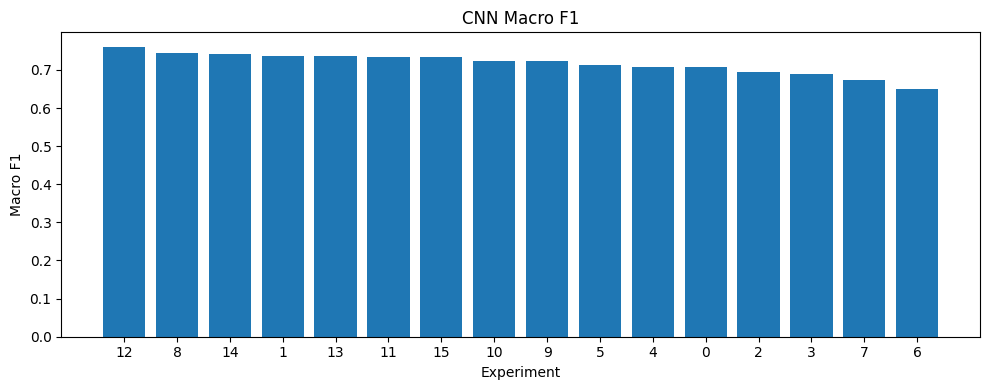

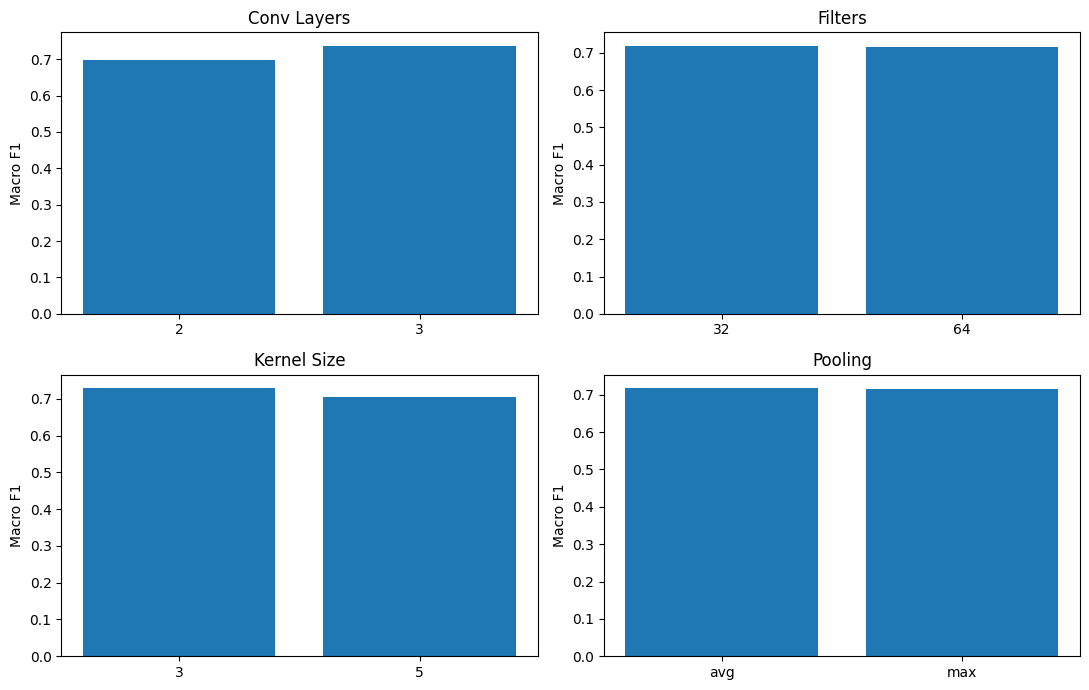

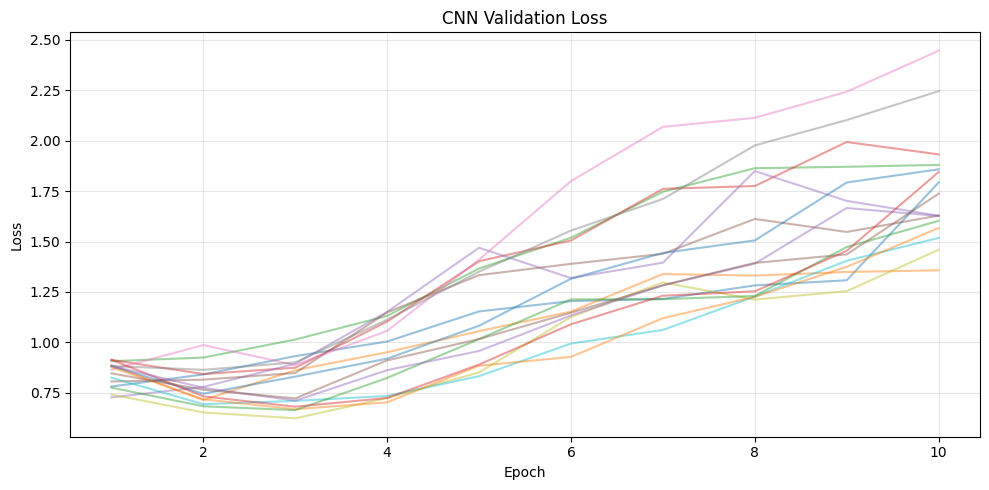

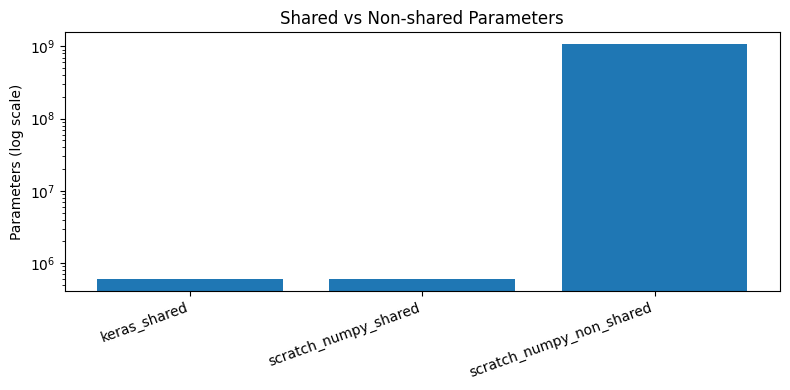

In [7]:
cnn_df = normalize_cnn_records(pd.read_csv(TABLE_DIR / 'cnn_records.csv'))
for group_col, out_name in [
    ('num_layers', 'cnn_by_num_layers.csv'),
    ('filters', 'cnn_by_filters.csv'),
    ('kernel_size', 'cnn_by_kernel_size.csv'),
    ('pooling', 'cnn_by_pooling_type.csv'),
]:
    cnn_df.groupby(group_col)[['macro_f1']].mean().reset_index().to_csv(TABLE_DIR / out_name, index=False)

plt.figure(figsize=(10, 4))
plt.bar(cnn_df['experiment'].astype(str), cnn_df['macro_f1'])
plt.xlabel('Experiment')
plt.ylabel('Macro F1')
plt.title('CNN Macro F1')
plt.tight_layout()
plt.savefig(FIG_DIR / 'cnn_macro_f1.png', dpi=150)
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for axis, (group_col, title) in zip(axes.ravel(), [('num_layers', 'Conv Layers'), ('filters', 'Filters'), ('kernel_size', 'Kernel Size'), ('pooling', 'Pooling')]):
    summary = cnn_df.groupby(group_col)['macro_f1'].mean().reset_index()
    axis.bar(summary[group_col].astype(str), summary['macro_f1'])
    axis.set_title(title)
    axis.set_ylabel('Macro F1')
fig.tight_layout()
fig.savefig(FIG_DIR / 'cnn_hyperparameters.png', dpi=150)
plt.show()

loss_rows = []
for row in cnn_df.itertuples():
    history_path = Path(getattr(row, 'history_path'))
    if not history_path.is_absolute():
        history_path = ROOT / history_path
    if not history_path.exists():
        continue
    with open(history_path, 'rb') as file:
        history = pickle.load(file)
    for epoch, (loss, val_loss) in enumerate(zip(history.get('loss', []), history.get('val_loss', [])), start=1):
        loss_rows.append({'experiment': int(row.experiment), 'epoch': epoch, 'loss': loss, 'val_loss': val_loss})
loss_df = pd.DataFrame(loss_rows)
if not loss_df.empty:
    plt.figure(figsize=(10, 5))
    for exp_id, part in loss_df.groupby('experiment'):
        plt.plot(part['epoch'], part['val_loss'], alpha=0.45, label=str(exp_id))
    plt.title('CNN Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'cnn_validation_loss.png', dpi=150)
    plt.show()

manual = pd.read_csv(TABLE_DIR / 'cnn_manual_comparison.csv')
if {'implementation', 'params'}.issubset(manual.columns):
    plt.figure(figsize=(8, 4))
    plt.bar(manual['implementation'], pd.to_numeric(manual['params'], errors='coerce'))
    plt.yscale('log')
    plt.xticks(rotation=20, ha='right')
    plt.ylabel('Parameters (log scale)')
    plt.title('Shared vs Non-shared Parameters')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'cnn_shared_parameters.png', dpi=150)
    plt.show()
